In [36]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from mpl_toolkits.mplot3d import Axes3D

### Реалізація генетичного алгоритму

In [37]:
def genetic_algorithm_2d(func, bounds,
                         pop_size=60,
                         generations=50,
                         crossover_p=0.8,
                         mutation_p=0.2):

    (xmin, xmax), (ymin, ymax) = bounds

    pop = np.column_stack((
        np.random.uniform(xmin, xmax, pop_size),
        np.random.uniform(ymin, ymax, pop_size)
    ))

    history = []
    populations = []

    for _ in range(generations):

        fitness = func(pop[:, 0], pop[:, 1])
        history.append(np.min(fitness))
        populations.append(pop.copy())

        # Турнірний відбір
        i1 = np.random.randint(0, pop_size, pop_size)
        i2 = np.random.randint(0, pop_size, pop_size)
        mask = (fitness[i1] < fitness[i2])[:, None]
        selected = np.where(mask, pop[i1], pop[i2])

        new_pop = selected.copy()

        # Схрещування
        for i in range(0, pop_size-1, 2):
            if np.random.rand() < crossover_p:
                alpha = np.random.rand()
                p1, p2 = new_pop[i], new_pop[i+1]
                new_pop[i]   = alpha*p1 + (1-alpha)*p2
                new_pop[i+1] = alpha*p2 + (1-alpha)*p1

        # Мутація
        for i in range(pop_size):
            if np.random.rand() < mutation_p:
                new_pop[i] += np.random.normal(0, 0.1, 2)

        new_pop[:, 0] = np.clip(new_pop[:, 0], xmin, xmax)
        new_pop[:, 1] = np.clip(new_pop[:, 1], ymin, ymax)

        pop = new_pop

    fitness = func(pop[:, 0], pop[:, 1])
    best_idx = np.argmin(fitness)

    return pop[best_idx], fitness[best_idx], history, populations

### Функція збереження 3D GIF

In [38]:
def save_gif_3d(func, bounds, populations, filename):

    (xmin, xmax), (ymin, ymax) = bounds

    x = np.linspace(xmin, xmax, 200)
    y = np.linspace(ymin, ymax, 200)
    X, Y = np.meshgrid(x, y)
    Z = func(X, Y)

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")
    ax.plot_surface(X, Y, Z, cmap="viridis", alpha=0.6)

    scat = ax.scatter([], [], [], c="red", s=40)

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_zlim(np.min(Z), np.max(Z))

    def update(frame):
        pop = populations[frame]
        z_vals = func(pop[:, 0], pop[:, 1])
        scat._offsets3d = (pop[:, 0], pop[:, 1], z_vals)
        ax.set_title(f"Generation {frame}")
        return scat,

    ani = animation.FuncAnimation(
        fig, update,
        frames=len(populations),
        interval=200
    )

    ani.save(filename, writer="pillow", fps=5)
    plt.close()

### Функції оптимізації

Branin

In [39]:
def branin(x, y):
    a = 1
    b = 5.1 / (4 * np.pi**2)
    c = 5 / np.pi
    r = 6
    s = 10
    t = 1 / (8 * np.pi)
    return a*(y - b*x**2 + c*x - r)**2 + s*(1 - t)*np.cos(x) + s

Easom

In [40]:
def easom(x, y):
    return -np.cos(x)*np.cos(y)*np.exp(-((x-np.pi)**2 + (y-np.pi)**2))

Goldstein-Price

In [41]:
def goldstein_price(x, y):
    term1 = (1 + (x+y+1)**2 *
            (19 - 14*x + 3*x**2 - 14*y + 6*x*y + 3*y**2))
    term2 = (30 + (2*x-3*y)**2 *
            (18 - 32*x + 12*x**2 + 48*y - 36*x*y + 27*y**2))
    return term1 * term2

Six-hump Camel

In [42]:
def six_hump_camel(x, y):
    return (4 - 2.1*x**2 + x**4/3)*x**2 + x*y + (-4 + 4*y**2)*y**2

### Графік залежності «ітерація – найкраще значення»

In [43]:
def compare_mutation_for_all_grid():

    functions = [
        ("Branin", branin, ((-5, 10), (0, 15))),
        ("Easom", easom, ((-10, 10), (-10, 10))),
        ("Goldstein-Price", goldstein_price, ((-2, 2), (-2, 2))),
        ("Six-hump Camel", six_hump_camel, ((-3, 3), (-2, 2)))
    ]

    mutation_values = [0.01, 0.1, 0.3]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for idx, (name, func, bounds) in enumerate(functions):

        ax = axes[idx]

        for m in mutation_values:

            _, _, history, _ = genetic_algorithm_2d(
                func,
                bounds=bounds,
                pop_size=80,
                generations=60,
                mutation_p=m
            )

            ax.plot(history, label=f"mutation_p = {m}")

        ax.set_title(name)
        ax.set_xlabel("Iteration")
        ax.set_ylabel("Best fitness")
        ax.grid(True)
        ax.legend()

    plt.tight_layout()
    plt.show()

In [44]:
def averaged_history(func, bounds, mutation_p, runs=5):

    all_histories = []

    for _ in range(runs):
        _, _, history, _ = genetic_algorithm_2d(
            func,
            bounds=bounds,
            pop_size=80,
            generations=60,
            mutation_p=mutation_p
        )
        all_histories.append(history)

    return np.mean(all_histories, axis=0)

### Запуск для кожної функції

Branin

In [ ]:
best, val, history, pops = genetic_algorithm_2d(
    branin,
    bounds=((-5, 10), (0, 15)),
    pop_size=80,
    generations=60
)

save_gif_3d(branin,
            ((-5, 10), (0, 15)),
            pops,
            "branin.gif")

Easom

In [51]:
best, val, history, pops = genetic_algorithm_2d(
    easom,
    bounds=((-10, 10), (-10, 10)),
    pop_size=100,
    generations=60
)

save_gif_3d(easom, ((-10, 10), (-10, 10)), pops, "easom.gif")

Goldstein–Price

In [47]:
best, val, history, pops = genetic_algorithm_2d(
    goldstein_price,
    bounds=((-2, 2), (-2, 2)),
    pop_size=80,
    generations=60
)

save_gif_3d(goldstein_price, ((-2, 2), (-2, 2)), pops, "goldstein.gif")

Six-hump Camel

In [48]:
best, val, history, pops = genetic_algorithm_2d(
    six_hump_camel,
    bounds=((-3, 3), (-2, 2)),
    pop_size=80,
    generations=60
)

save_gif_3d(six_hump_camel, ((-3, 3), (-2, 2)), pops, "camel.gif")

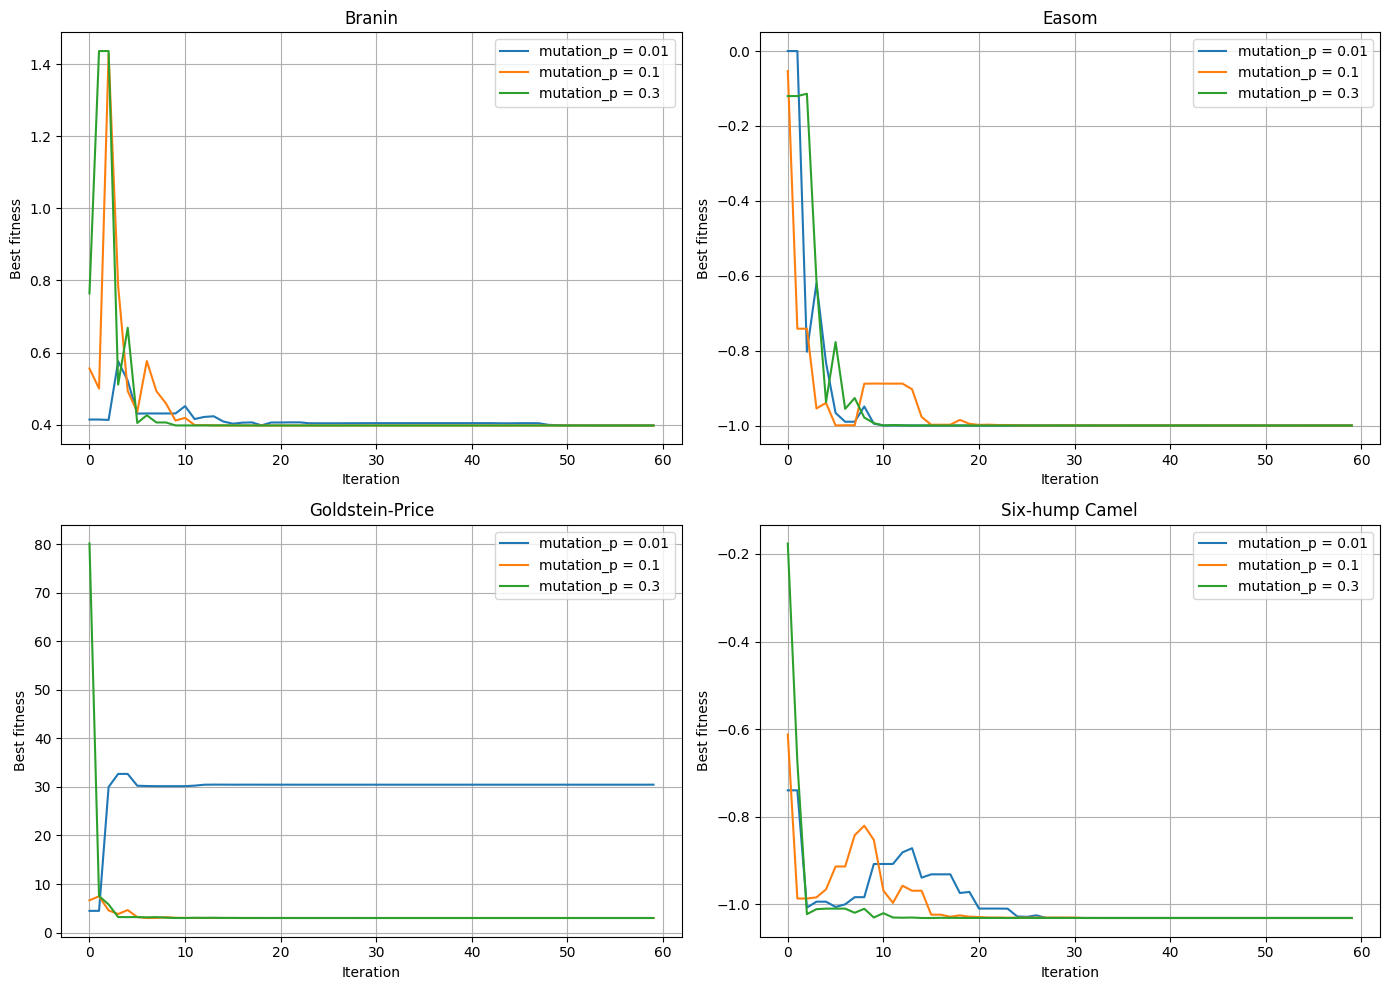

In [49]:
compare_mutation_for_all_grid()